# Seaborn 可视化分析作业

请按照“一个小题 + 一个代码块”的格式完成作答。每个代码块只完成对应小题，不要把所有内容写在同一个单元格中。

覆盖知识点：`seaborn` 基础绘图流程、`histplot`、`kdeplot`、`countplot`、`scatterplot`、`jointplot`、`barplot`、`boxplot`、`violinplot`、`pairplot`、`hue` 分组、分类排序、图表标题、坐标轴标签和业务解读。

## 场景

公司数据产品部正在规划一套“生物观测数据可视化看板”。目标用户是业务研究员和项目负责人，他们希望通过一组清晰、稳定、可解释的图表，快速判断样本结构、变量分布、群体差异和指标之间的关系。

本次作业请你基于课堂中的 Seaborn 案例方法，完成企鹅观测数据的探索性可视化分析。重点不是堆砌图表数量，而是让每张图都有明确业务问题、图形选择理由和简短分析结论。

## 数据说明

使用课堂案例中的企鹅观测数据集 `penguins`。数据字段通常包括：

- `species`：企鹅物种。
- `island`：观测岛屿。
- `bill_length_mm`：嘴峰长度，单位为毫米。
- `bill_depth_mm`：嘴峰深度，单位为毫米。
- `flipper_length_mm`：鳍长，单位为毫米。
- `body_mass_g`：体重，单位为克。
- `sex`：性别。

正式分析前，请完成必要的数据加载、缺失值处理和数据概览。

## 第 1 题：数据加载与基础检查

业务要求：看板上线前，产品部需要确认数据字段完整、样本可用，避免后续图表基于脏数据生成。

1. 导入本次分析需要的基础库。
2. 加载 `penguins` 数据集。
3. 查看数据规模、字段类型和前 5 行。
4. 处理缺失值，并说明处理后的样本量变化。

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
# seaborn要更新到0.12.0版本及以上，否则barplot的errorbar属性会报错
import seaborn as sns
import numpy as np
# 设置支持中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
# 读取数据文件
penguins = pd.read_csv('./data/penguins.csv')
# 查看数据规模、字段类型和前五行
print(penguins.describe())
print(penguins.dtypes)
print(penguins.head())
# 处理缺失值(这里采用删除的方式)
before_rows = penguins.shape[0]
penguins = penguins.dropna()
after_rows = penguins.shape[0]
print(f"删除缺失值前:{before_rows}行")
print(f"删除缺失值后:{after_rows}行")

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Tor

In [60]:
print(sns.__version__)

0.13.2


## 第 2 题：物种样本结构分析

业务要求：研究员需要先确认不同物种的样本数量是否均衡，避免后续结论受到样本结构影响。

1. 统计不同 `species` 的样本数量。
2. 使用计数图展示物种样本分布。
3. 图表按样本数量从高到低排序。
4. 在图下方用 1-2 句话说明样本是否均衡。

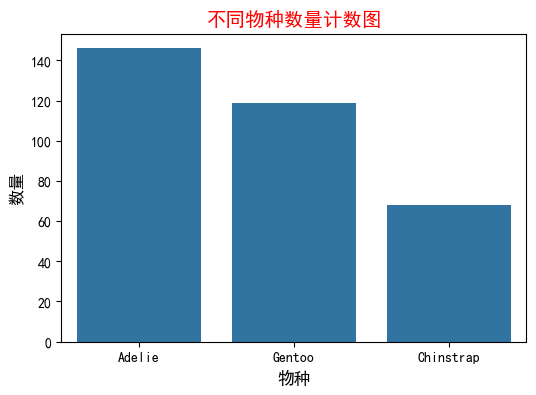

In [61]:
# 使用计数图countplot
plt.figure(figsize=(6, 4))
sns.countplot(data=penguins, x='species', order=penguins['species'].value_counts().index)
plt.xlabel('物种', fontsize=12)
plt.ylabel('数量', fontsize=12)
plt.title('不同物种数量计数图', fontsize=14, color='red')
plt.show()
# Adelie样本最多，Chinstrap样本最少，物种样本数量不完全均衡。

## 第 3 题：嘴峰长度分布分析

业务要求：产品部希望在看板中展示核心体型指标的整体分布，帮助研究员判断数据是否集中、是否存在长尾或多个峰值。

1. 选择 `bill_length_mm` 作为分析字段。
2. 绘制直方图，并叠加核密度曲线。
3. 设置清晰的标题、横轴单位和纵轴含义。
4. 简要说明该指标的集中区间和分布形态。

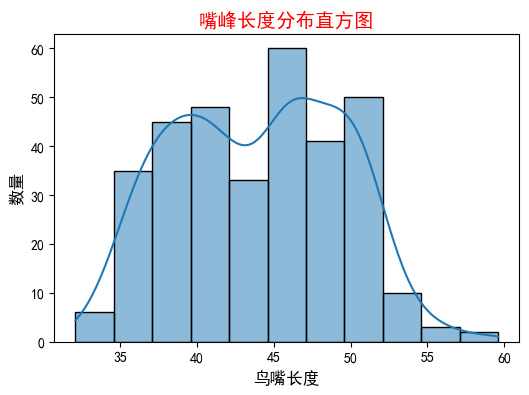

In [62]:
# 使用直方图histplot或核密度估计图kdeplot
plt.figure(figsize=(6, 4))
sns.histplot(penguins,x='bill_length_mm', kde=True)
# sns.kdeplot(data=penguins, x='bill_length_mm')
plt.xlabel('鸟嘴长度', fontsize=12)
plt.ylabel('数量', fontsize=12)
plt.title('嘴峰长度分布直方图', fontsize=14, color='red')
plt.show()
# 企鹅嘴峰长度在40mm和47.5mm附近分布最多

## 第 4 题：观测岛屿样本来源分析

业务要求：项目负责人需要判断样本是否集中在少数岛屿，以便评估数据采集范围是否充分。

1. 统计不同 `island` 的样本数量。
2. 使用计数图展示岛屿样本来源。
3. 判断样本来源是否存在明显集中。

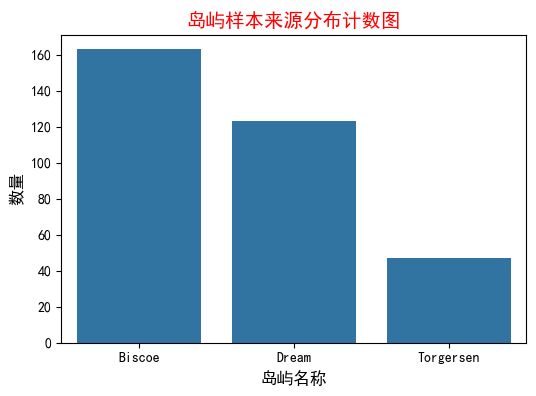

In [63]:
# 使用计数图countplot统计不同island的样本数量
plt.figure(figsize=(6, 4))
sns.countplot(data=penguins, x='island', order=penguins['island'].value_counts().index)
plt.xlabel('岛屿名称', fontsize=12)
plt.ylabel('数量', fontsize=12)
plt.title('岛屿样本来源分布计数图', fontsize=14, color='red')
plt.show()
# 样本主要集中在Biscoe和Dream岛，Torgersen岛样本较少，来源存在一定集中。

## 第 5 题：体重与鳍长关系分析

业务要求：研究团队希望观察体重与鳍长是否存在正向关系，并进一步查看不同性别之间是否存在差异。

1. 以 `body_mass_g` 为横轴，`flipper_length_mm` 为纵轴绘制散点图。
2. 使用 `sex` 做颜色分组。
3. 设置图例、标题和坐标轴单位。
4. 说明两项指标之间是否存在明显关系。

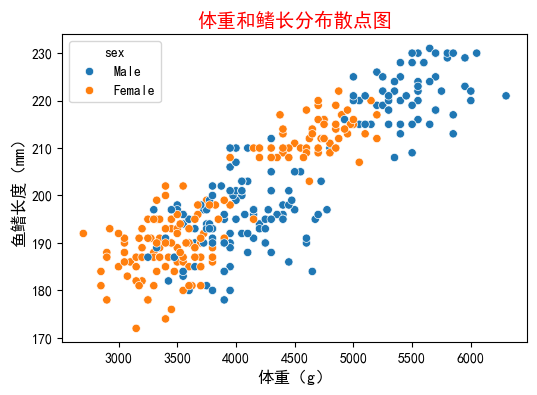

In [64]:
# 使用散点图scatterplot分析体重和鳍长是否有正向关系
plt.figure(figsize=(6, 4))
# hue='xxx' 使用xx作为颜色分组
sns.scatterplot(data=penguins, x='body_mass_g', y='flipper_length_mm', hue='sex')
plt.xlabel('体重（g）', fontsize=12)
plt.ylabel('鱼鳍长度（mm）', fontsize=12)
plt.title('体重和鳍长分布散点图', fontsize=14, color='red')
plt.show()
# 体重和鳍长存在明显的正相关关系

## 第 6 题：体重与鳍长密集区域分析

业务要求：当散点较多时，产品部希望用更适合观察密集区域的图形，定位样本主要集中在哪些体重和鳍长区间。

1. 使用联合分布图或蜂窝图展示 `body_mass_g` 与 `flipper_length_mm`。
2. 说明样本最密集的大致区间。
3. 与上一题散点图进行简单对比，说明这种图形适合解决什么问题。

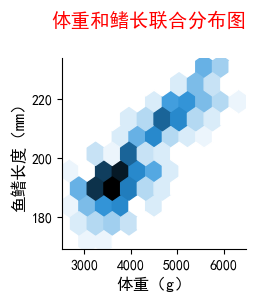

In [65]:
# 使用联合分布图jointplot或蜂窝图(jointplot设置kind='hex')
# sns.jointplot(data=penguins, x='body_mass_g', y='flipper_length_mm', kind='hist')
body_flipper_plot = sns.jointplot(
    data=penguins,
    x='body_mass_g',
    y='flipper_length_mm',
    kind='hex',
    height=3
)
# 去除分布图上方和右侧的柱状图
body_flipper_plot.ax_marg_x.remove()
body_flipper_plot.ax_marg_y.remove()
body_flipper_plot.ax_joint.set_xlabel('体重（g）', fontsize=12)
body_flipper_plot.ax_joint.set_ylabel('鱼鳍长度（mm）', fontsize=12)
body_flipper_plot.fig.suptitle('体重和鳍长联合分布图', fontsize=14, color='red')
plt.show()
# 样本最密集的大致区间为（3800g,180mm）以及(4500g,215mm)附近
# 蜂窝图和二维直方图适合点数很多时查看分布

## 第 7 题：二维核密度分布分析

业务要求：看板需要展示体重与鳍长的连续型联合分布，让用户快速识别高密度区域。

1. 使用二维核密度图展示 `body_mass_g` 与 `flipper_length_mm`。
2. 图形需要体现填充效果和密度差异。
3. 说明高密度区域与前两题观察是否一致。

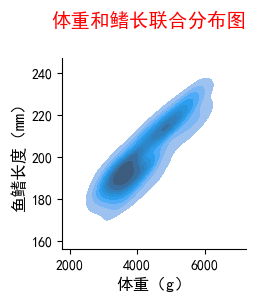

In [66]:
# 使用二维核密度分布分析图(jointplot设置kind='kde')
body_flipper_plot = sns.jointplot(
    data=penguins,
    x='body_mass_g',
    y='flipper_length_mm',
    kind='kde',
    fill=True, # fill:True 体现填充效果
    height=3
)
# 去除分布图上方和右侧的柱状图
body_flipper_plot.ax_marg_x.remove()
body_flipper_plot.ax_marg_y.remove()
body_flipper_plot.ax_joint.set_xlabel('体重（g）', fontsize=12)
body_flipper_plot.ax_joint.set_ylabel('鱼鳍长度（mm）', fontsize=12)
body_flipper_plot.fig.suptitle('体重和鳍长联合分布图', fontsize=14, color='red')
plt.show()
# 样本最密集的大致区间为（3800g,180mm）以及(4500g,215mm)附近
# 二维核密度图适合关键连续变量的高密度区域，与蜂窝图观察到的集中区间基本一致

## 第 8 题：不同物种平均嘴峰长度对比

业务要求：研究员希望对比不同物种的平均嘴峰长度，判断该指标是否具备物种区分度。

1. 按 `species` 比较 `bill_length_mm` 的平均水平。
2. 使用条形图展示对比结果。
3. 关闭或弱化不必要的误差线，突出均值对比。
4. 说明哪个物种的平均嘴峰长度更高。

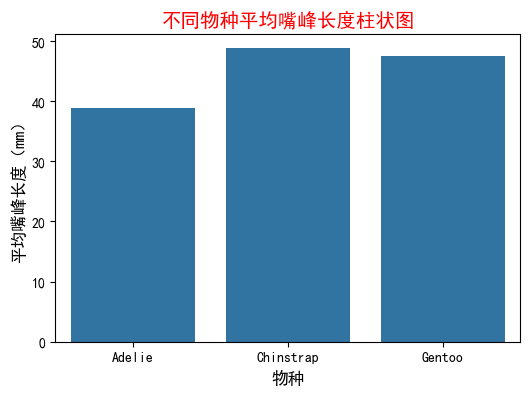

In [67]:
# 使用条形图对比不同物种的平均嘴峰长度
# estimator属性：使用哪个统计量
# errorbar(v0.12.0新版功能)：代表柱子上的竖线含义（默认为'ci'，即置信区间（95%）），此处不显示
plt.figure(figsize=(6, 4))
sns.barplot(data=penguins, x='species', y='bill_length_mm',
            estimator=np.mean, errorbar=None)
plt.xlabel('物种', fontsize=12)
plt.ylabel('平均嘴峰长度（mm）', fontsize=12)
plt.title('不同物种平均嘴峰长度柱状图', fontsize=14, color='red')
plt.show()
# Chinstrap的平均嘴峰长度最高，Adelie最低，嘴峰长度对物种有一定辨识度

## 第 9 题：不同物种嘴峰长度离散程度分析

业务要求：仅看均值不够，产品部还需要展示不同物种内部差异、异常值和中位数位置。

1. 使用箱线图比较不同 `species` 的 `bill_length_mm` 分布。
2. 重点观察中位数、四分位范围和异常点。
3. 简要说明哪个物种内部差异更明显。

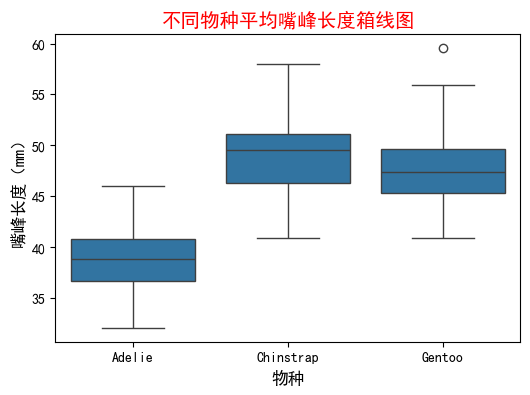

In [68]:
# 使用箱线图boxplot比较不同物种的鸟嘴长度差异
plt.figure(figsize=(6, 4))
sns.boxplot(penguins, x='species', y='bill_length_mm')
plt.xlabel('物种', fontsize=12)
plt.ylabel('嘴峰长度（mm）', fontsize=12)
plt.title('不同物种平均嘴峰长度箱线图', fontsize=14, color='red')
plt.show()
# Chinstrap种类的企鹅内部差异最明显

## 第 10 题：不同物种嘴峰长度分布形态分析

业务要求：为了更直观地展示分布形态，产品部希望在箱线图之外补充小提琴图，观察不同物种的密度变化。

1. 使用小提琴图比较不同 `species` 的 `bill_length_mm`。
2. 与箱线图结论进行对照。
3. 说明小提琴图相比箱线图多提供了哪些信息。

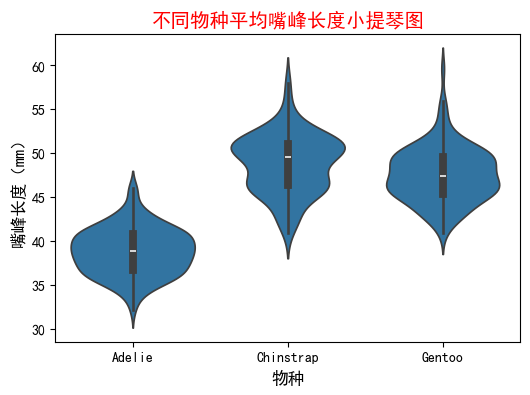

In [69]:
# 使用小提琴图
plt.figure(figsize=(6, 4))
sns.violinplot(penguins, x='species', y='bill_length_mm')
plt.xlabel('物种', fontsize=12)
plt.ylabel('嘴峰长度（mm）', fontsize=12)
plt.title('不同物种平均嘴峰长度小提琴图', fontsize=14, color='red')
plt.show()
# 和箱线图对比得出结论一致（Chinstrap物种内部差异最明显）
# 小提琴图比箱线图多了不同嘴峰长度对应企鹅的数量信息

## 第 11 题：多变量成对关系总览

业务要求：项目负责人希望在一个视图中快速查看多个体型指标之间的两两关系，并判断不同物种是否形成明显分组。

1. 选择 `bill_length_mm`、`bill_depth_mm`、`flipper_length_mm`、`body_mass_g` 等核心数值字段。
2. 使用成对关系图展示变量之间的两两关系。
3. 按 `species` 进行颜色分组。
4. 总结哪些变量组合最能区分物种。

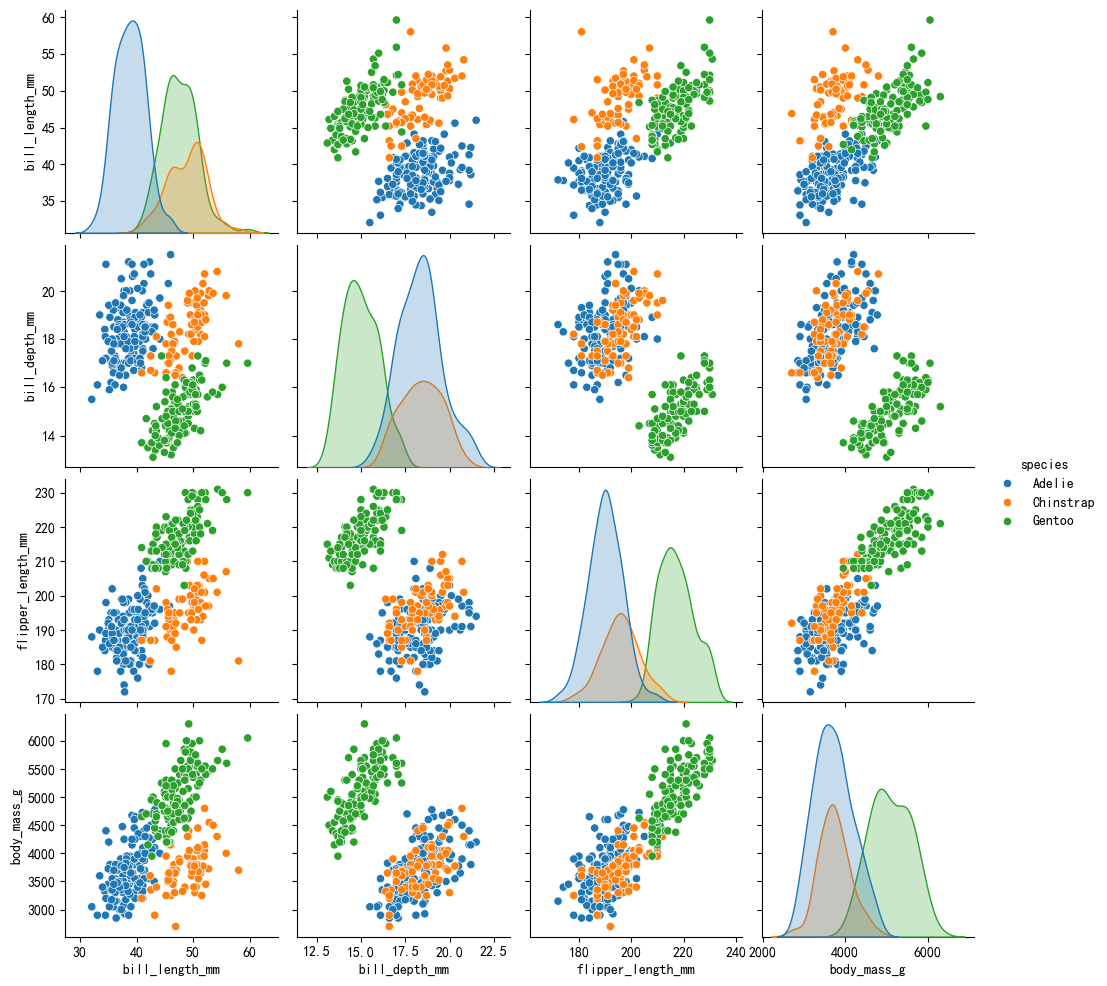

In [70]:
# 使用成对关系图（pairplot）展示变量之间的两两关系
sns.pairplot(penguins,
             vars=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'],
             hue='species')
plt.show()
# 结论：(bill_length,bill_depth)(bill_length,flipper_length)
# (bill_length,body_mass)的变量组合最能区分物种

## 第 12 题：可视化分析小结

业务要求：请基于前面的图表，完成一段 5-8 句话的分析小结。

小结至少包含：

1. 样本结构是否均衡。
2. 哪些体型指标差异明显。
3. 体重与鳍长是否存在关系。
4. 哪些图表最适合放入正式看板。
5. 后续还可以补充哪些数据或分析维度。

本题写在 Markdown 中即可。

1.样本结构数量不太均衡，Chinstrap种类数量偏少。
2.不同物种的体型差异明显，特别在鳍长、体重、嘴峰长度等指标。
3.体重和鳍长存在正相关关系。
4.正式看板建议保留物种计数图、体重与鳍长散点图、物种分组箱线图、pairplot总览。
5.后续可以补充采样时间、年龄、观测地点经纬度等字段，用于分析季节变化和空间分布差异。